# Problem 3 Solution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
def gradient_descent(x_train, y_train, w0, alpha, num_steps):
  """
  Performs gradient descent to learn the weights of a linear regression model.

  Args:
    x_train (np.ndarray): The training input features.
    y_train (np.ndarray): The training target values.
    w0 (np.ndarray): The initial weights.
    alpha (float): The learning rate.
    num_steps (int): The number of gradient descent steps.

  Returns:
    np.ndarray: The learned weights.
  """
  # PRO TIP: CREATE DEEP COPY of arrays passed as args to avoid changing them
  # Your code here (~2 lines)
  x_train_copy = np.copy(x_train)
  y_train_copy = np.copy(y_train)
  w0 = np.copy(w0)

  losses = []

  for i in range(num_steps):

    # compute loss (~2 lines)
    # Your code here
    y_hat = np.dot(x_train_copy, w0)
    loss = np.mean((y_hat - y_train_copy) ** 2)
    losses.append(loss)
    
    # Placeholder for loss, remove after implementing
    # loss = 0 
    print(f'Training loss = {loss:.3f}')

    # compute gradients and update params (~2 lines)
    # Your code here
    gradient = (2 / x_train_copy.shape[0]) * np.dot(x_train_copy.T, (y_hat - y_train_copy))
    w0 -= alpha * gradient
    w = w0

  return w, losses


def train_linear_regression(x_train, y_train, alpha=0.01):
    """
    Initializes and trains a linear regression model.

    Args:
      x_train (np.ndarray): The training input features.
      y_train (np.ndarray): The training target values.

    Returns:
      np.ndarray: The trained model weights.
    """
    # PRO TIP: setting a random seed makes the experiments reproducible (hopefully in other systems too)
    np.random.seed(541)
    
    # Initialize weights (~2 lines)
    # Your code here 

    w0 = np.random.randn(x_train.shape[1])
    # b = np.random.randn(1)

    # Placeholder for w0, remove after implementing
    # w0 = np.zeros(x_train.shape[1])
    print(f'Model coefficients: {np.round(w0,3)}')

    # Make initial prediction (~1 line)
    # Your code here
    y_pred = np.dot(x_train, w0)

    # Placeholder for y_pred, remove after implementing
    # y_pred = np.zeros(y_train.shape)
    print(y_pred[:5])

    # Calculate initial loss (~1-2 lines)
    # PRO TIP: tracking the train loss at the beginning and during optimization is
    # key for debugging, determining convergence
    # Your code here
    loss = np.mean((y_pred - y_train) ** 2)

    # Placeholder for loss, remove after implementing
    # loss = 0
    print(f'Training loss = {loss:.3f}')

    # Run gradient descent
    w, losses = gradient_descent(x_train, y_train, w0, alpha, 100)

    return w, losses

def plot_loss_curves(x_train: np.ndarray, y_train: np.ndarray, alphas: list[float]):
    """
    Plots the loss curves for different learning rates.

    Args:
      alphas (list of float): The learning rates to evaluate.
    """
    plt.figure(figsize=(10, 6))
    for alpha in alphas:
        # Train model with the given alpha
        w, losses = train_linear_regression(x_train, y_train, alpha=alpha)
        plt.plot(losses, label=f'alpha={alpha}')
    
    plt.title('Loss Curves for Different Learning Rates')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()
    plt.savefig('loss_curves.pdf')

def load_data():
    """
    Loads the training and testing data from .npy files.

    Returns:
      tuple: A tuple containing the training and testing data.
    """
    try:
        X_tr = np.reshape(np.load("age_regression/age_regression_Xtr.npy"), (-1, 48*48))
        ytr = np.load("age_regression/age_regression_ytr.npy")
        X_te = np.reshape(np.load("age_regression/age_regression_Xte.npy"), (-1, 48*48))
        yte = np.load("age_regression/age_regression_yte.npy")
        print(X_tr.shape, ytr.shape, X_te.shape, yte.shape)
    except FileNotFoundError:
        print("Dataset files not found. Please download them and place them in the same directory.")
        return
            
    return X_tr, ytr, X_te, yte

In [5]:
def main():
    """
    Main function to load data, pre-process, train, and evaluate the model.
    """
    # Load data from files
    # Make sure you have the .npy files in the same directory as this script
    X_tr, ytr, X_te, yte = load_data()

    # (optional) Pre-processing

    # PRO TIP: center and normalize the features from training set (~4 lines)
    # Your code here

    print("Normalizing the features...")
    # train_mean = np.mean(X_tr, axis=0)
    # train_std = np.std(X_tr, axis=0)
    # train_std[train_std == 0] = 1.0

    # X_tr = (X_tr - train_mean) / train_std
    # X_te = (X_te - train_mean) / train_std
    print("Feature normalization complete.")
    

    # PRO TIP: prepend a 1 to each of the observations in X_tr and X_te (~2 lines)
    # This way you can treat the bias just as a regular weight
    # Your code here
    print("Prepending a 1 to each observation in X_tr and X_te...")
    X_tr = np.hstack((np.ones((X_tr.shape[0], 1)), X_tr))
    X_te = np.hstack((np.ones((X_te.shape[0], 1)), X_te))
    print("Prepending complete.")
    print(f'X_tr shape after prepending: {X_tr.shape}, X_te shape after prepending: {X_te.shape}')

    # Train model
    print("Training the linear regression model...")
    w, losses = train_linear_regression(X_tr, ytr, alpha=2e-4)

    # Report fMSE cost on the training and testing data (separately)
    # Your code here (~4-6 lines)
    train_loss = np.mean((np.dot(X_tr, w) - ytr) ** 2)
    test_loss = np.mean((np.dot(X_te, w) - yte) ** 2)
    print(f'Training loss after training = {train_loss:.3f}')
    print(f'Testing loss after training = {test_loss:.3f}')
    # plot_loss_curves(X_tr, ytr, alphas=[1e-4, 2e-4, 5e-5])

main()
    

(5000, 2304) (5000,) (2500, 2304) (2500,)
Normalizing the features...
Feature normalization complete.
Prepending a 1 to each observation in X_tr and X_te...
Prepending complete.
X_tr shape after prepending: (5000, 2305), X_te shape after prepending: (2500, 2305)
Training the linear regression model...
Model coefficients: [ 0.803  0.039  0.109 ...  0.882 -1.13  -0.027]
[-36.12891776 -26.73343558 -29.29599607 -23.1388821  -25.61559408]
Training loss = 5066.104
Training loss = 5066.104
Training loss = 2873.065
Training loss = 1691.228
Training loss = 1054.294
Training loss = 710.991
Training loss = 525.917
Training loss = 426.108
Training loss = 372.246
Training loss = 343.144
Training loss = 327.384
Training loss = 318.815
Training loss = 314.120
Training loss = 311.515
Training loss = 310.035
Training loss = 309.163
Training loss = 308.618
Training loss = 308.250
Training loss = 307.978
Training loss = 307.758
Training loss = 307.567
Training loss = 307.391
Training loss = 307.224
Train

(5000, 2304) (5000,) (2500, 2304) (2500,)
Model coefficients: [ 0.803  0.039  0.109 ... -0.098  0.882 -1.13 ]
[-33.81815081 -25.70298082 -32.41025507 -26.61713116 -21.19385922]
Training loss = 5086.127
Training loss = 5086.127
Training loss = 3902.802
Training loss = 3012.818
Training loss = 2343.452
Training loss = 1840.010
Training loss = 1461.357
Training loss = 1176.557
Training loss = 962.343
Training loss = 801.214
Training loss = 680.012
Training loss = 588.837
Training loss = 520.245
Training loss = 468.638
Training loss = 429.805
Training loss = 400.580
Training loss = 378.579
Training loss = 362.014
Training loss = 349.535
Training loss = 340.130
Training loss = 333.038
Training loss = 327.684
Training loss = 323.638
Training loss = 320.575
Training loss = 318.252
Training loss = 316.486
Training loss = 315.139
Training loss = 314.106
Training loss = 313.310
Training loss = 312.692
Training loss = 312.208
Training loss = 311.825
Training loss = 311.518
Training loss = 311.269

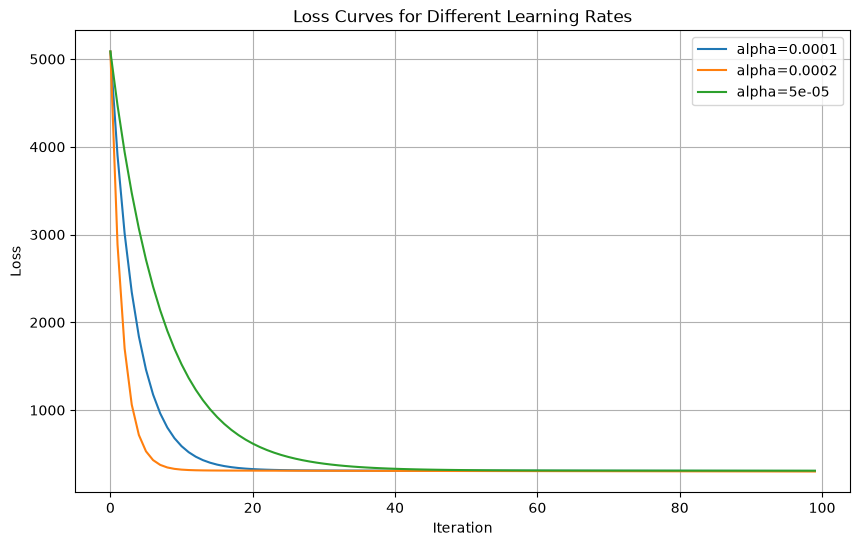

<Figure size 640x480 with 0 Axes>

In [6]:
X_tr, ytr, X_te, yte = load_data()
plot_loss_curves(X_tr, ytr, alphas=[1e-4, 2e-4, 5e-5])